# Monocle2 Olsson 数据集完整复现

**原R教程**: https://cole-trapnell-lab.github.io/monocle-release/tutorial_data/Olsson_dataset_analysis_final.html  
**数据**: Olsson et al. 2016, Nature 537:698 — 小鼠造血分化 scRNA-seq (640 cells × 23955 genes)

使用 `ov.single.Monocle` 完整复现造血谱系分析流程。

## 1. 加载环境

In [1]:
import sys, os
sys.path.insert(0, '/scratch/users/steorra/analysis/omicverse_dev/omicverse')

import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from scipy import sparse

import omicverse as ov
from omicverse.single import Monocle

np.random.seed(2017)  # 匹配R教程

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
print(f'omicverse version: {ov.__version__}')

/scratch/users/steorra/env/CMAP/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


/scratch/users/steorra/env/CMAP/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


omicverse version: 2.1.2rc1


## 2. 加载 Olsson 数据

原始 RSEM 矩阵 → TPM 归一化 → AnnData。

In [2]:
DATA_DIR = '/scratch/users/steorra/analysis/26_monoclepy/olsson_data/Nature_hta_paper/input'

hta_exprs = pd.read_csv(f'{DATA_DIR}/Olsson_RSEM_SingleCellRNASeq.csv', index_col=0)
print(f'Raw: {hta_exprs.shape} (genes × cells)')

tpm_mat = hta_exprs.values.astype(np.float64)
col_sums = tpm_mat.sum(axis=0); col_sums[col_sums == 0] = 1
tpm_mat = tpm_mat / col_sums[None, :] * 1e6

cell_names = hta_exprs.columns.tolist()
groups = [c.split('.') for c in cell_names]
sample_sheet = pd.DataFrame({
    'groups_1': [g[0] for g in groups],
    'groups_2': [g[1] if len(g) > 1 else '' for g in groups],
    'groups_3': [g[2] if len(g) > 2 else '' for g in groups],
}, index=cell_names)

types = list(sample_sheet['groups_1'].values)
for i in range(452, 593): types[i] = types[i] + '_knockout'
for i in range(593, 640):
    types[i] = types[i] + '_' + sample_sheet['groups_2'].iloc[i] + '_knockout'
sample_sheet['Type'] = types

var_df = pd.DataFrame({'gene_short_name': hta_exprs.index}, index=hta_exprs.index)
adata = ad.AnnData(X=tpm_mat.T, obs=sample_sheet, var=var_df)
print(f'\nAnnData: {adata.n_obs} cells × {adata.n_vars} genes')
print(sample_sheet['Type'].value_counts())

Raw: (23955, 640) (genes × cells)

AnnData: 640 cells × 23955 genes
Type
Gmp                            132
Cmp                             94
Lsk                             93
Gfi1_knockout                   79
LK                              63
Irf8_knockout                   62
GG1                             37
IG2                             33
Gfi1--Irf8--_E2_knockout         2
Gfi1--Irf8--_B1_knockout         1
Gfi1--Irf8--_D1_knockout         1
Gfi1--Irf8--_E1_knockout         1
Gfi1--Irf8--_Gfi11_knockout      1
Gfi1--Irf8--_C1_knockout         1
Gfi1--Irf8--_H1_knockout         1
Gfi1--Irf8--_A2_knockout         1
Gfi1--Irf8--_C2_knockout         1
Gfi1--Irf8--_B2_knockout         1
Gfi1--Irf8--_D2_knockout         1
Gfi1--Irf8--_Gfi12_knockout      1
Gfi1--Irf8--_A3_knockout         1
Gfi1--Irf8--_B3_knockout         1
Gfi1--Irf8--_E3_knockout         1
Gfi1--Irf8--_F3_knockout         1
Gfi1--Irf8--_Gfi13_knockout      1
Gfi1--Irf8--_H3_knockout         1
Gfi1--Irf8--_A4_k

## 3. Census 归一化 + 预处理

In [3]:
mono_all = Monocle(adata)
adata_abs = mono_all.relative2abs(method='num_genes')

mono_all = Monocle(adata_abs)
mono_all.preprocess()
mono_all.set_ordering_filter(adata_abs.var_names.tolist())
mono_all

Monocle(640 cells × 23955 genes)
  preprocessed: ✓
  ordering genes: 23955

## 4. 筛选 WT 细胞 (Fig 1b subset)

只保留野生型（Lsk, Cmp, Gmp, LK）。

In [4]:
wt_types = ['Lsk', 'Cmp', 'Gmp', 'LK']
adata_fig1b = adata_abs[adata_abs.obs['Type'].isin(wt_types)].copy()
print(f'WT cells: {adata_fig1b.n_obs}')

# Load paper cluster annotations
fig1b = pd.read_csv(f'{DATA_DIR}/fig1b.txt', sep='\t', index_col=0)
fig1b_row = fig1b.iloc[0, 1:]
cell_map = {c.split(':')[-1]: v for c, v in zip(fig1b.columns[1:], fig1b_row.values)}

cluster_names = {1:'HSCP-1', 2:'HSCP-2', 3:'Meg', 4:'Eryth', 5:'Multi-Lin',
                  6:'MDP', 7:'Mono', 8:'Gran', 9:'Myelocyte'}
paper_cluster = []
for cn in adata_fig1b.obs_names:
    c = cell_map.get(cn, 0)
    try: c = int(float(c))
    except: c = 0
    paper_cluster.append(cluster_names.get(c, 'Unassigned'))
adata_fig1b.obs['cluster'] = pd.Categorical(paper_cluster)

ordering_genes_fig1b = [g for g in fig1b.index if g in adata_fig1b.var_names]
print(f'fig1b ordering genes: {len(ordering_genes_fig1b)}')
print(adata_fig1b.obs['cluster'].value_counts())

WT cells: 382
fig1b ordering genes: 532
cluster
Mono         95
HSCP-2       63
HSCP-1       59
Gran         59
MDP          33
Multi-Lin    28
Meg          18
Myelocyte    14
Eryth        13
Name: count, dtype: int64


## 5. WT Monocle 分析器 + 初始 tSNE 聚类

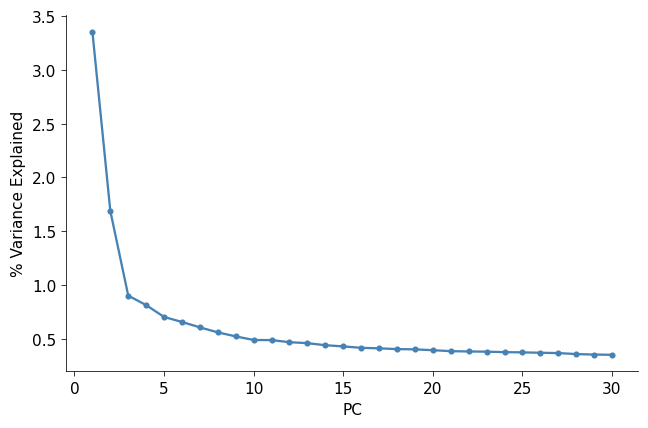

In [5]:
mono = Monocle(adata_fig1b)
mono.set_ordering_filter(ordering_genes_fig1b)
mono.preprocess()

mono.plot_pc_variance_explained(max_components=30, figsize=(6, 4))
plt.show()

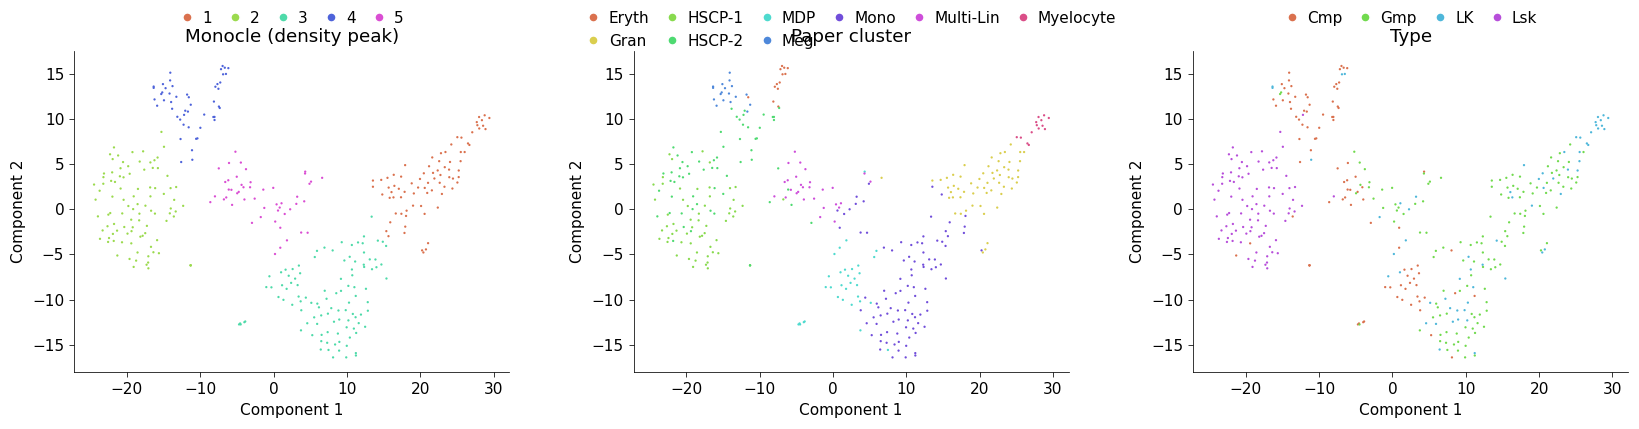

In [6]:
mono.reduce_dimension(max_components=2, reduction_method='tSNE',
                       norm_method='log', num_dim=12, verbose=False)
mono.cluster_cells(method='densityPeak', num_clusters=5)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
mono.plot_cell_clusters(color_by='Cluster', ax=axes[0])
axes[0].set_title('Monocle (density peak)')
mono.plot_cell_clusters(color_by='cluster', ax=axes[1])
axes[1].set_title('Paper cluster')
mono.plot_cell_clusters(color_by='Type', ax=axes[2])
axes[2].set_title('Type')
plt.tight_layout()
plt.show()

## 6. Cluster DE → Top 1000 基因

In [7]:
%%time
de_cluster = mono.differential_gene_test(
    fullModelFormulaStr='~Cluster', cores=-1, verbose=False,
)
top1000 = de_cluster.sort_values('qval').head(1000).index.tolist()
print(f'显著 DE: {(de_cluster["qval"]<0.01).sum()}')
de_cluster.sort_values('qval').head(10)[['pval','qval','status']]

显著 DE: 1442
CPU times: user 488 ms, sys: 131 ms, total: 618 ms
Wall time: 4.35 s


         pval  qval status
Kdm6b     0.0   0.0     OK
Dgka      0.0   0.0     OK
Dhrs11    0.0   0.0     OK
Dennd4c   0.0   0.0     OK
Depdc1b   0.0   0.0     OK
Depdc5    0.0   0.0     OK
Desi1     0.0   0.0     OK
Dfna5     0.0   0.0     OK
Dgat2     0.0   0.0     OK
Rassf7    0.0   0.0     OK

## 7. DDRTree 4D + orderCells

4维 DDRTree 能更好捕获多分支谱系结构。

In [8]:
%%time
mono.set_ordering_filter(top1000)
mono.reduce_dimension(
    max_components=4, reduction_method='DDRTree',
    scaling=True, maxIter=100,
    lambda_param=20 * mono.adata.n_obs, ncenter=250,
).order_cells()

print(mono)
print(f'Branch points: {mono.branch_points}')

Monocle(382 cells × 23955 genes)
  preprocessed: ✓
  ordering genes: 1000
  reduced: DDRTree
  ordered: pseudotime [0.00, 15.45], 8 states
Branch points: ['Y_31', 'Y_56', 'Y_118', 'Y_141', 'Y_161', 'Y_181']
CPU times: user 6.41 s, sys: 380 ms, total: 6.79 s
Wall time: 466 ms


## 8. 轨迹可视化

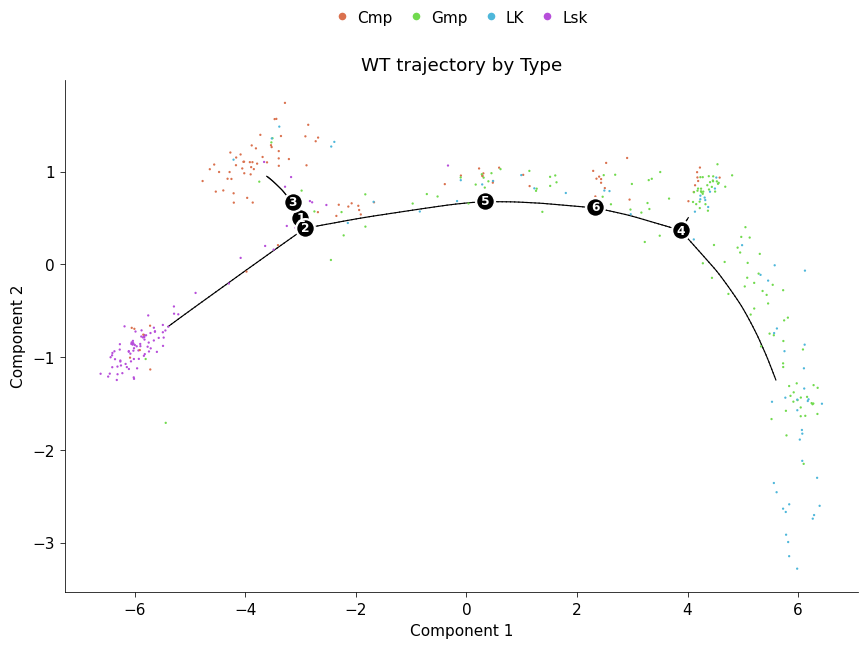

In [9]:
mono.plot_trajectory(color_by='Type', cell_size=1.5)
plt.title('WT trajectory by Type')
plt.show()

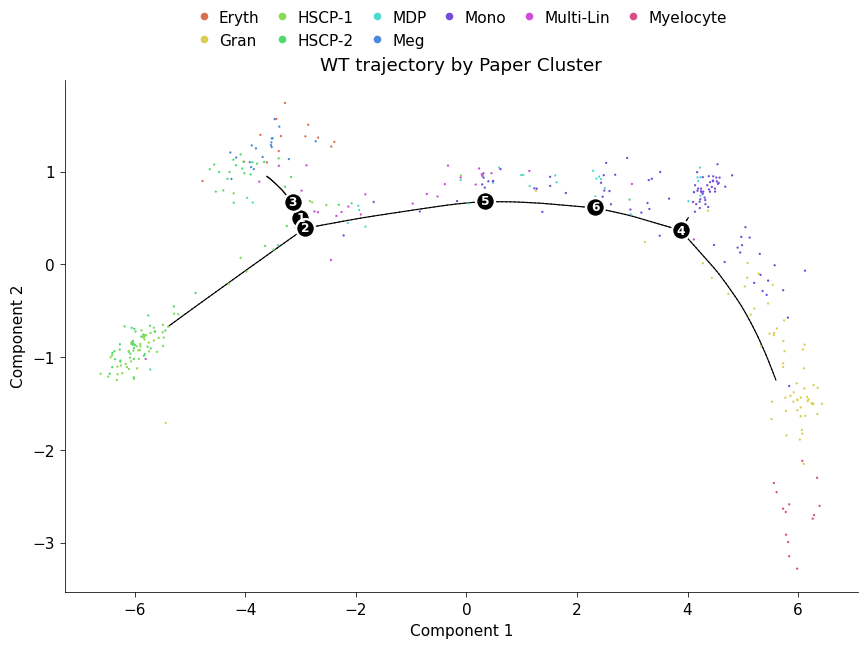

In [10]:
mono.plot_trajectory(color_by='cluster', cell_size=1.5)
plt.title('WT trajectory by Paper Cluster')
plt.show()

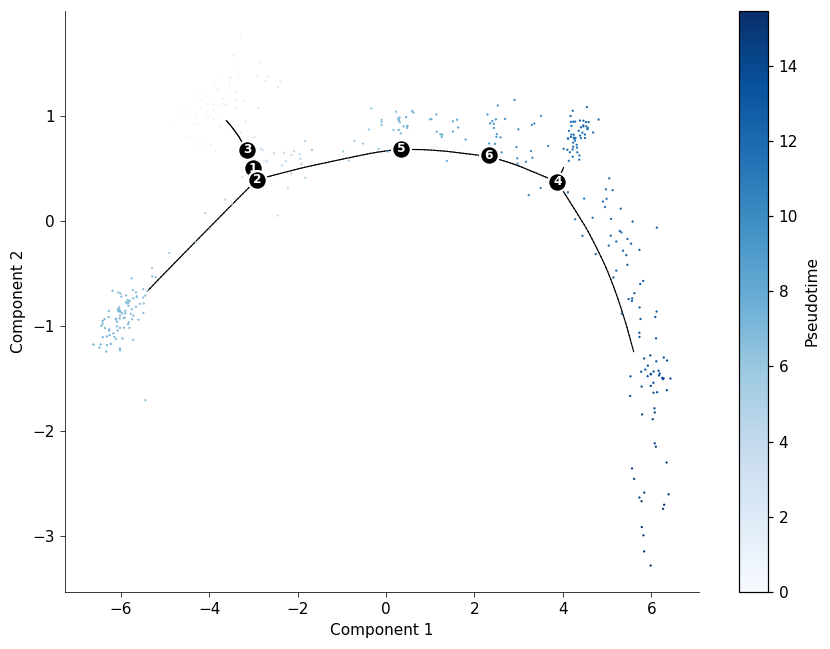

In [11]:
mono.plot_trajectory(color_by='Pseudotime', cell_size=1.5)
plt.show()

## 9. 复杂轨迹（树状布局）

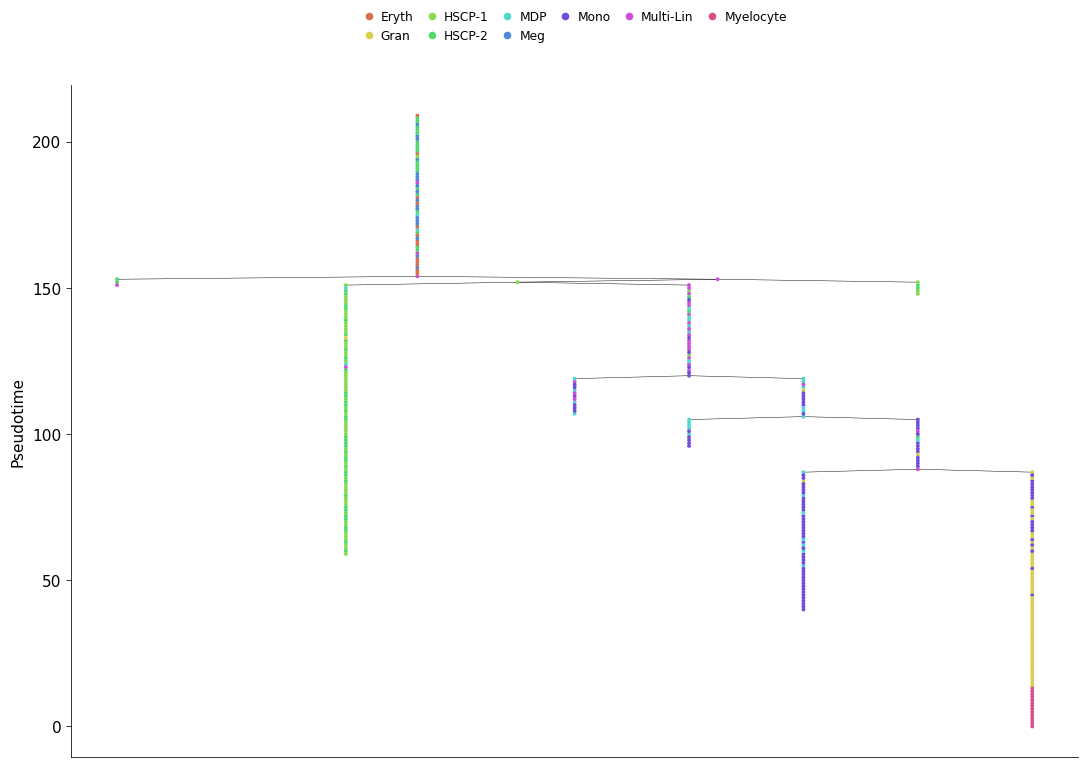

In [12]:
mono.plot_complex_cell_trajectory(color_by='cluster',
                                    cell_size=0.8, cell_link_size=0.3,
                                    figsize=(10, 7))
plt.show()

## 10. BEAM 分支差异表达

In [13]:
%%time
beam = mono.BEAM(branch_point=1, cores=-1)
sig_beam = beam[beam['qval'] < 0.01]
print(f'\nBEAM sig genes: {len(sig_beam)}/{len(beam)}')
beam.sort_values('qval').head(10)[['pval','qval','status']]


BEAM sig genes: 1484/23955
CPU times: user 671 ms, sys: 193 ms, total: 865 ms
Wall time: 1min 18s


        pval  qval status
Gm6225   0.0   0.0     OK
Gm9958   0.0   0.0     OK
Gna14    0.0   0.0     OK
Gmnn     0.0   0.0     OK
Gnl1     0.0   0.0     OK
Gne      0.0   0.0     OK
Gnb4     0.0   0.0     OK
Gnb2     0.0   0.0     OK
Gorab    0.0   0.0     OK
Gm5111   0.0   0.0     OK

## 11. 多分支 Pseudotime 曲线

Markers found: ['Car1', 'Elane', 'Car2', 'Prtn3']


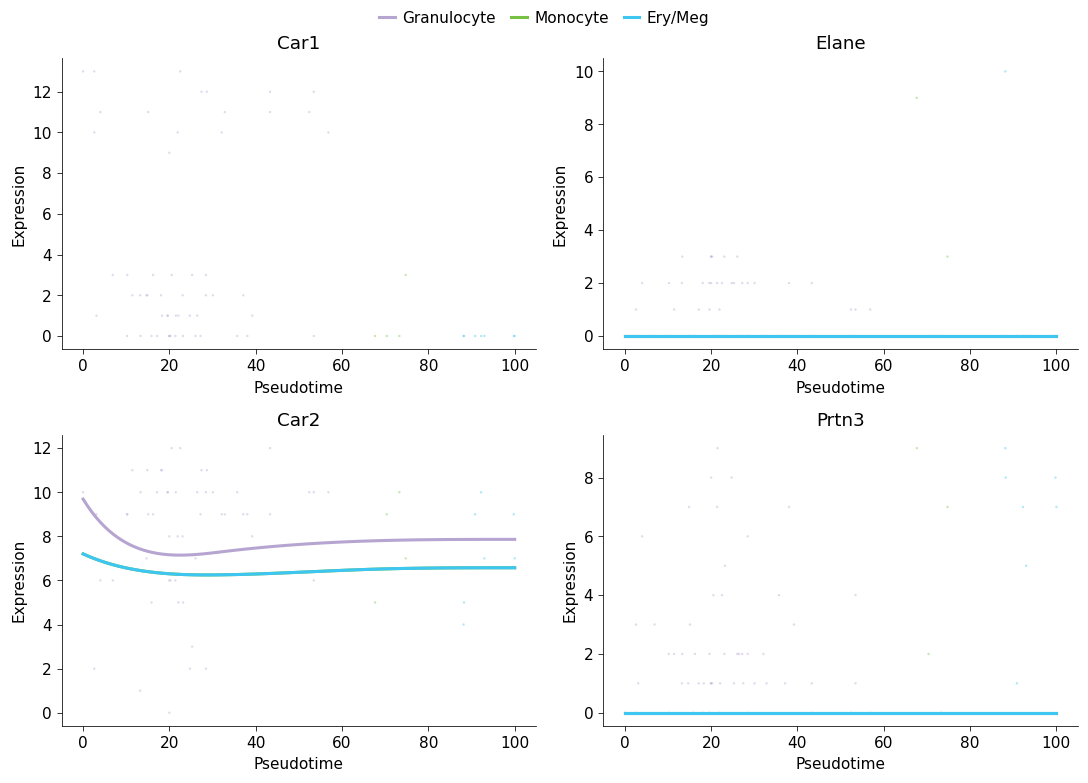

In [14]:
markers = ['Car1', 'Elane', 'Car2', 'Prtn3']
markers_found = [g for g in markers if g in mono.adata.var_names]
print(f'Markers found: {markers_found}')

all_states = sorted(mono.adata.obs['State'].unique())
branches = list(all_states[:3])
names = ['Granulocyte', 'Monocyte', 'Ery/Meg'][:len(branches)]

mono.plot_multiple_branches_pseudotime(
    genes=markers_found, branches=branches, branches_name=names,
    ncol=2, figsize=(10, 7))
plt.show()

## 12. 多分支热图

Using 50 BEAM genes for heatmap


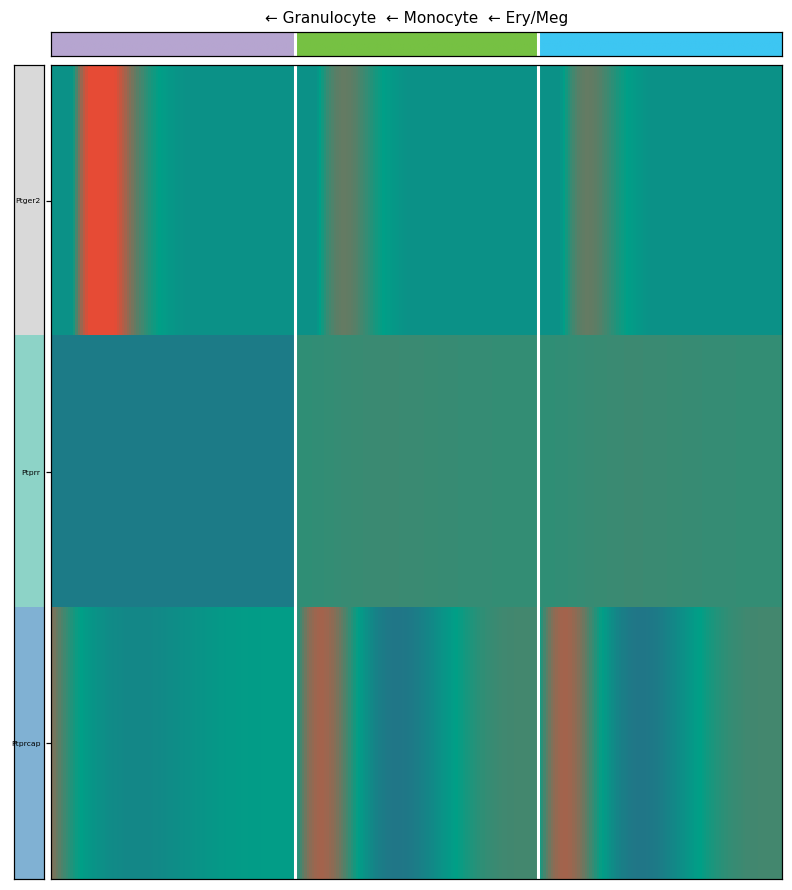

In [15]:
top_beam = sig_beam.sort_values("qval").head(50).index.tolist()
top_beam = [g for g in top_beam if g in mono.adata.var_names]
print(f"Using {len(top_beam)} BEAM genes for heatmap")

# Create a sub-Monocle restricted to BEAM genes
import sys
sys.setrecursionlimit(10000)  # dendrogram recursion for large matrices

sub_adata = mono.adata[:, top_beam].copy()
# Copy trajectory metadata
sub_adata.uns["monocle"] = mono.adata.uns["monocle"]
mono_sub = Monocle(sub_adata)

mono_sub.plot_multiple_branches_heatmap(
    branches=branches, branches_name=names,
    num_clusters=4, show_rownames=True, figsize=(9, 10))
plt.show()

## 13. State × Cluster 对应热图

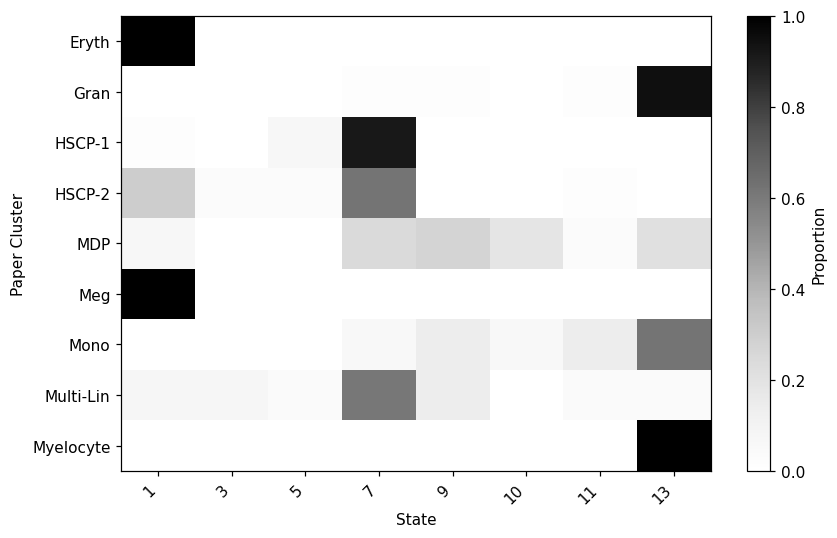

In [16]:
state_cluster = pd.crosstab(mono.adata.obs['State'], mono.adata.obs['cluster'])
state_cluster_n = state_cluster.div(state_cluster.sum(axis=0), axis=1)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
im = ax.imshow(state_cluster_n.T, cmap='Greys', aspect='auto')
ax.set_xticks(range(len(state_cluster_n.index)))
ax.set_xticklabels(state_cluster_n.index, rotation=45, ha='right')
ax.set_yticks(range(len(state_cluster_n.columns)))
ax.set_yticklabels(state_cluster_n.columns)
ax.set_xlabel('State'); ax.set_ylabel('Paper Cluster')
plt.colorbar(im, ax=ax, label='Proportion')
plt.tight_layout()
plt.show()

## 总结

`Monocle` 类 API 让整个 Olsson 造血分化分析变得非常简洁：

```python
mono = Monocle(adata_fig1b)
mono.set_ordering_filter(fig1b_genes).preprocess()
mono.reduce_dimension(method='tSNE', num_dim=12).cluster_cells(method='densityPeak', num_clusters=5)

de = mono.differential_gene_test(fullModelFormulaStr='~Cluster')
top = de.sort_values('qval').head(1000).index.tolist()

mono.set_ordering_filter(top).reduce_dimension(max_components=4, lambda_param=20*mono.adata.n_obs).order_cells()
beam = mono.BEAM(branch_point=1)
```

- ✅ 同一个对象，链式调用
- ✅ 所有结果存在 `mono.adata` 中
- ✅ DDRTree 比R快约 **25×**